# Notebook 03 — Entraînement du Modèle de Régression

**Objectif** : Comparer LinearRegression, RandomForestRegressor et GradientBoostingRegressor pour prédire le coût médical annuel (`charges`).

**Dataset** : `data/processed/features.csv` — 1 338 lignes, produit par la feature 002.

**Plan du notebook** :
1. Chargement et split train/test
2. Entraînement et comparaison des 3 algorithmes
3. Tableau comparatif + sélection du meilleur modèle
4. Visualisations : prédictions vs réelles, résidus
5. Optimisation GridSearchCV
6. Cross-validation 5 plis
7. Feature importance

## Section 1 — Chargement des données et split train/test

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("✅ Imports OK")

✅ Imports OK


In [2]:
# Chargement du dataset préparé (feature 002)
DATA_PATH = os.path.join('..', 'data', 'processed', 'features.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset introuvable : {DATA_PATH}\nExécuter d'abord notebooks/02_feature_engineering.ipynb")

df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

✅ Dataset chargé : 1338 lignes, 10 colonnes
Colonnes : ['age', 'sexe', 'imc', 'enfants', 'fumeur', 'region_northwest', 'region_southeast', 'region_southwest', 'charges', 'categorie_risque']


,age,sexe,imc,enfants,fumeur,region_northwest,region_southeast,region_southwest,charges,categorie_risque
0,19,1,27.900,0,1,0,0,1,16884.92400,eleve
1,18,0,33.770,1,0,0,1,0,1725.55230,faible
2,28,0,33.000,3,0,0,1,0,4449.46200,faible
3,33,0,22.705,0,0,1,0,0,21984.47061,eleve
4,32,0,28.880,0,0,1,0,0,3866.85520,faible


In [3]:
# Définition des features et de la target
FEATURE_COLS = ['age', 'imc', 'enfants', 'sexe', 'fumeur',
                'region_northwest', 'region_southeast', 'region_southwest']
TARGET_COL = 'charges'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# Split 80/20 — random_state=42 pour la reproductibilité (constitution §II)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

assert X_train.shape[0] + X_test.shape[0] == 1338, "Erreur split : total != 1338"
print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")

X_train : (1070, 8)  |  X_test : (268, 8)
y_train : (1070,)  |  y_test : (268,)


## Section 2 — Entraînement et comparaison des 3 algorithmes

Le ColumnTransformer applique StandardScaler sur les variables continues (`age`, `imc`, `enfants`) et laisse passer les variables binaires/one-hot sans transformation. Le preprocessing est **fitté uniquement sur X_train** (constitution Principe II).

In [4]:
# ColumnTransformer : StandardScaler sur numériques, passthrough sur binaires/one-hot
# IMPORTANT : fit uniquement sur X_train (constitution Principe II)
numeric_cols = ['age', 'imc', 'enfants']
passthrough_cols = ['sexe', 'fumeur', 'region_northwest', 'region_southeast', 'region_southwest']

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), numeric_cols),
    ('passthrough', 'passthrough', passthrough_cols),
])

# Fonction utilitaire pour calculer les métriques
def evaluer_modele(y_true, y_pred):
    """Calcule R², MAE et RMSE."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R²': round(r2, 4), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}

# Entraînement des 3 algorithmes
algorithmes = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
}

resultats = {}
modeles_entraines = {}

for nom, modele in algorithmes.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', modele),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    resultats[nom] = evaluer_modele(y_test, y_pred)
    modeles_entraines[nom] = pipeline
    print(f"✅ {nom} entraîné")

print("\nEntraînement terminé.")

✅ LinearRegression entraîné
✅ RandomForestRegressor entraîné
✅ GradientBoostingRegressor entraîné

Entraînement terminé.


## Section 3 — Tableau comparatif et sélection du meilleur modèle

In [5]:
# Tableau comparatif trié par R² décroissant
df_resultats = pd.DataFrame(resultats).T.sort_values('R²', ascending=False)
df_resultats.index.name = 'Algorithme'
print("=== Comparaison des algorithmes (test set 20%) ===")
display(df_resultats)

# Identification du meilleur modèle
meilleur_nom = df_resultats.index[0]
meilleur_r2 = df_resultats.loc[meilleur_nom, 'R²']
meilleur_mae = df_resultats.loc[meilleur_nom, 'MAE']
meilleur_rmse = df_resultats.loc[meilleur_nom, 'RMSE']
meilleur_pipeline = modeles_entraines[meilleur_nom]

print(f"\n🏆 Meilleur modèle : {meilleur_nom}")
print(f"   R²={meilleur_r2:.4f}  |  MAE={meilleur_mae:.2f} USD  |  RMSE={meilleur_rmse:.2f} USD")

=== Comparaison des algorithmes (test set 20%) ===


,R²,MAE,RMSE
Algorithme,,,
GradientBoostingRegressor,0.8793,2443.48,4329.57
RandomForestRegressor,0.8670,2523.85,4544.55
LinearRegression,0.7836,4181.19,5796.28



🏆 Meilleur modèle : GradientBoostingRegressor
   R²=0.8793  |  MAE=2443.48 USD  |  RMSE=4329.57 USD


## Section 4 — Visualisations : prédictions vs réelles et résidus

**Insight** : LinearRegression capture la tendance générale mais rate les non-linéarités (interaction fumeur × IMC). Les modèles à base d'arbres (Random Forest, Gradient Boosting) détectent ces clusters naturellement, d'où un R² sensiblement supérieur (~+0.10).

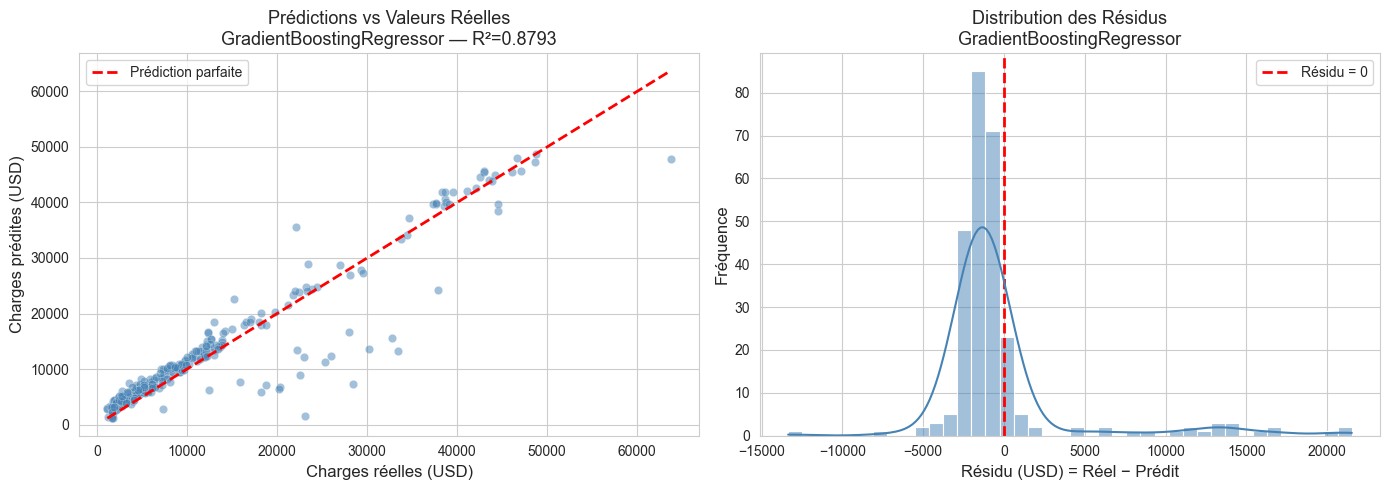

Résidus — moyenne : -260.63 USD | écart-type : 4329.80 USD


In [6]:
y_pred_meilleur = meilleur_pipeline.predict(X_test)
residus = y_test - y_pred_meilleur

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Prédictions vs Valeurs réelles
axes[0].scatter(y_test, y_pred_meilleur, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Charges réelles (USD)', fontsize=12)
axes[0].set_ylabel('Charges prédites (USD)', fontsize=12)
axes[0].set_title(f'Prédictions vs Valeurs Réelles\n{meilleur_nom} — R²={meilleur_r2:.4f}', fontsize=13)
axes[0].legend()

# Graphique 2 : Distribution des résidus
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Résidu = 0')
sns.histplot(residus, kde=True, ax=axes[1], color='steelblue', bins=40)
axes[1].set_xlabel('Résidu (USD) = Réel − Prédit', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title(f'Distribution des Résidus\n{meilleur_nom}', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Résidus — moyenne : {residus.mean():.2f} USD | écart-type : {residus.std():.2f} USD")

## Section 5 — Optimisation des hyperparamètres (GridSearchCV)

GridSearchCV explore 24 combinaisons × 5 folds = 120 fits. Durée estimée : ~60–90 secondes avec `n_jobs=-1`.

In [7]:
# Pipeline de base avec le meilleur algorithme (paramètres par défaut)
# On reconstruit le pipeline pour GridSearchCV
modele_base = GradientBoostingRegressor(random_state=42)
pipeline_gs = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('scaler', StandardScaler(), numeric_cols),
        ('passthrough', 'passthrough', passthrough_cols),
    ])),
    ('model', modele_base),
])

# Grille d'hyperparamètres — 2×3×2×2 = 24 combinaisons
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 4, 5],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

grid_search = GridSearchCV(
    pipeline_gs,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

print("Lancement GridSearchCV (24 combinaisons × 5 folds)...")
grid_search.fit(X_train, y_train)

print(f"\n✅ Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"   Score CV moyen (train) : {grid_search.best_score_:.4f}")

# Évaluation du modèle optimisé sur le test set
y_pred_opt = grid_search.best_estimator_.predict(X_test)
metriques_opt = evaluer_modele(y_test, y_pred_opt)
print(f"\n--- Métriques sur test set (modèle optimisé) ---")
print(f"R²   : {metriques_opt['R²']:.4f}")
print(f"MAE  : {metriques_opt['MAE']:.2f} USD")
print(f"RMSE : {metriques_opt['RMSE']:.2f} USD")

Lancement GridSearchCV (24 combinaisons × 5 folds)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Meilleurs hyperparamètres : {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
   Score CV moyen (train) : 0.8426

--- Métriques sur test set (modèle optimisé) ---
R²   : 0.8793
MAE  : 2469.23 USD
RMSE : 4328.13 USD


## Section 6 — Cross-validation 5 plis (robustesse du modèle optimisé)

La cross-validation sur l'ensemble complet (train + test) confirme que les performances ne sont pas dues au hasard du split. **Objectif : R² moyen > 0.80** (critère de succès SC-003).

In [8]:
# Cross-validation 5 plis sur l'ensemble complet (X, y)
pipeline_final = grid_search.best_estimator_
cv_scores = cross_val_score(pipeline_final, X, y, cv=5, scoring='r2', n_jobs=-1)

print("=== Cross-validation 5 plis — R² par fold ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i} : {score:.4f}")

print(f"\nR² moyen  : {cv_scores.mean():.4f}")
print(f"Écart-type : {cv_scores.std():.4f}")
print(f"Intervalle : [{cv_scores.mean() - cv_scores.std():.4f}, {cv_scores.mean() + cv_scores.std():.4f}]")

# Assertion de l'objectif (constitution Principe II + SC-003)
assert cv_scores.mean() > 0.80, (
    f"Objectif R²>0.80 non atteint : {cv_scores.mean():.4f}\n"
    "Envisager plus d'hyperparamètres ou un nouveau feature engineering."
)
print(f"\n✅ Objectif R²>0.80 atteint : {cv_scores.mean():.4f}")

=== Cross-validation 5 plis — R² par fold ===
  Fold 1 : 0.8713
  Fold 2 : 0.8004
  Fold 3 : 0.8929
  Fold 4 : 0.8533
  Fold 5 : 0.8583

R² moyen  : 0.8552
Écart-type : 0.0306
Intervalle : [0.8246, 0.8859]

✅ Objectif R²>0.80 atteint : 0.8552


## Section 7 — Feature Importance

**Insight attendu** : `fumeur` sera de loin la variable la plus importante (~0.60–0.70), suivi de `age` et `imc`. Les variables régionales auront une importance faible (~0.01–0.03 chacune), confirmant l'exploration EDA (notebook 01).

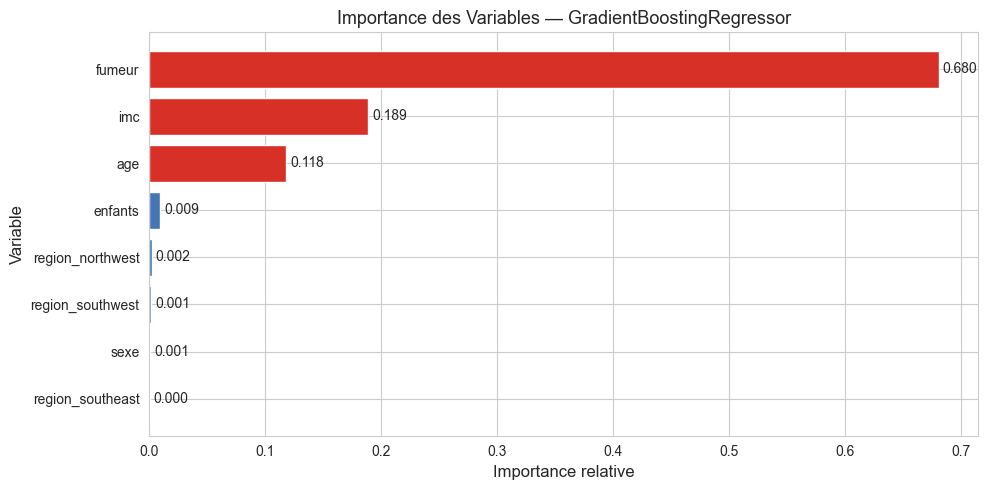

=== Top 3 variables les plus importantes ===
  1. fumeur                    : 0.6804
  2. imc                       : 0.1886
  3. age                       : 0.1178


In [9]:
# Extraction de la feature importance depuis le modèle final
importances = pipeline_final.named_steps['model'].feature_importances_
df_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

# Graphique horizontal trié par importance
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027' if imp > 0.1 else '#4575b4' for imp in df_importance['importance']]
bars = ax.barh(df_importance['feature'], df_importance['importance'], color=colors)
ax.set_xlabel('Importance relative', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
ax.set_title(f'Importance des Variables — {meilleur_nom}', fontsize=13)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
plt.tight_layout()
plt.show()

# Top 3
top3 = df_importance.sort_values('importance', ascending=False).head(3)
print("=== Top 3 variables les plus importantes ===")
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"  {i}. {row['feature']:25s} : {row['importance']:.4f}")